# Connect to Google Drive and Import Packages


In [ ]:
# (Colab Drive mount removed — this repo reads the CSVs from data/ locally)


In [ ]:
import os
# (Colab chdir removed — run from the repo root)


In [54]:
import warnings
from scipy.optimize._linesearch import LineSearchWarning  # Import the warning class
warnings.filterwarnings("ignore", category=LineSearchWarning)

import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import t
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, LeaveOneOut, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import itertools
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.tree import export_text

In [4]:
pd.set_option('display.max_columns', None)

# Standings Data EDA

In [18]:
standings_df = pd.read_csv('data/combined_league_standings_2010_2023.csv')
standings_df

,League,Season,Rk,Team,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Notes
0,Premier League,2010-2011,1,Manchester Utd,38,23,11,4,78,37,41,80,2.11,→ Champions League via league finish
1,Premier League,2010-2011,2,Chelsea,38,21,8,9,69,33,36,71,1.87,→ Champions League via league finish
2,Premier League,2010-2011,3,Manchester City,38,21,8,9,60,33,27,71,1.87,→ Champions League via league finish
3,Premier League,2010-2011,4,Arsenal,38,19,11,8,72,43,29,68,1.79,→ Champions League via league finish
4,Premier League,2010-2011,5,Tottenham,38,16,14,8,55,46,9,62,1.63,→ Europa League via league finish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1675,MLS,2023-2024,10,Portland Timbers,34,11,10,13,46,58,-12,43,1.26,NaN
1676,MLS,2023-2024,11,Minnesota Utd,34,10,11,13,46,51,-5,41,1.21,NaN
1677,MLS,2023-2024,12,Austin,34,10,9,15,49,55,-6,39,1.15,NaN
1678,MLS,2023-2024,13,LA Galaxy,34,8,12,14,51,67,-16,36,1.06,NaN


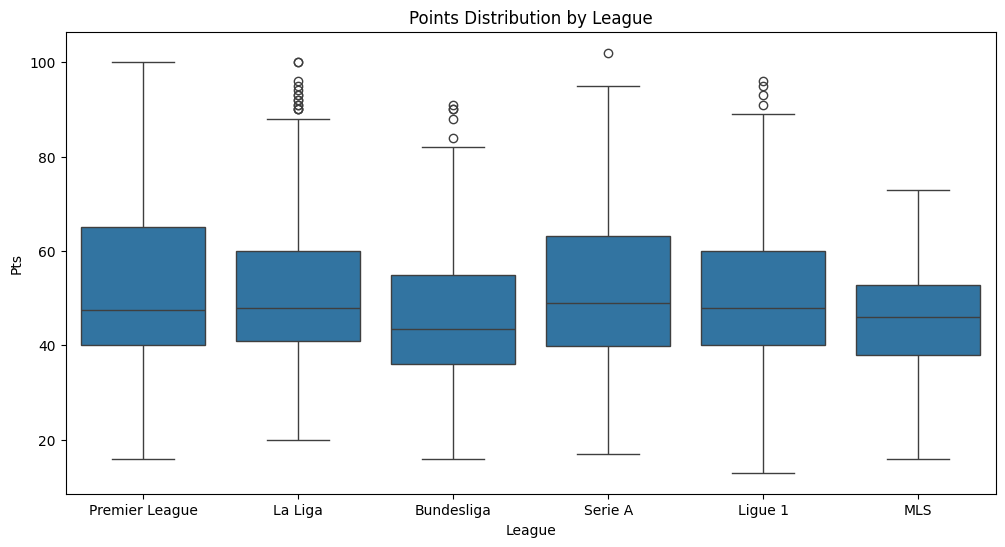

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="League", y="Pts", data=standings_df)
plt.title("Points Distribution by League")
plt.show()

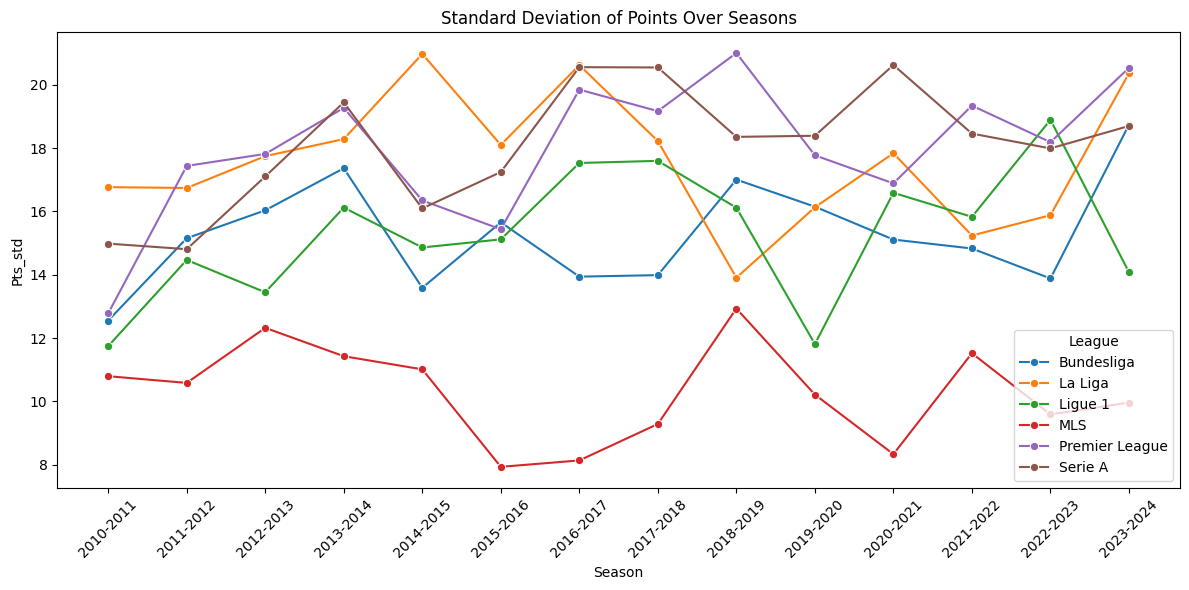

In [8]:
pts_std = standings_df.groupby(["League", "Season"])["Pts"].std().reset_index(name="Pts_std")

plt.figure(figsize=(12, 6))
sns.lineplot(x="Season", y="Pts_std", hue="League", data=pts_std, marker="o")
plt.title("Standard Deviation of Points Over Seasons")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

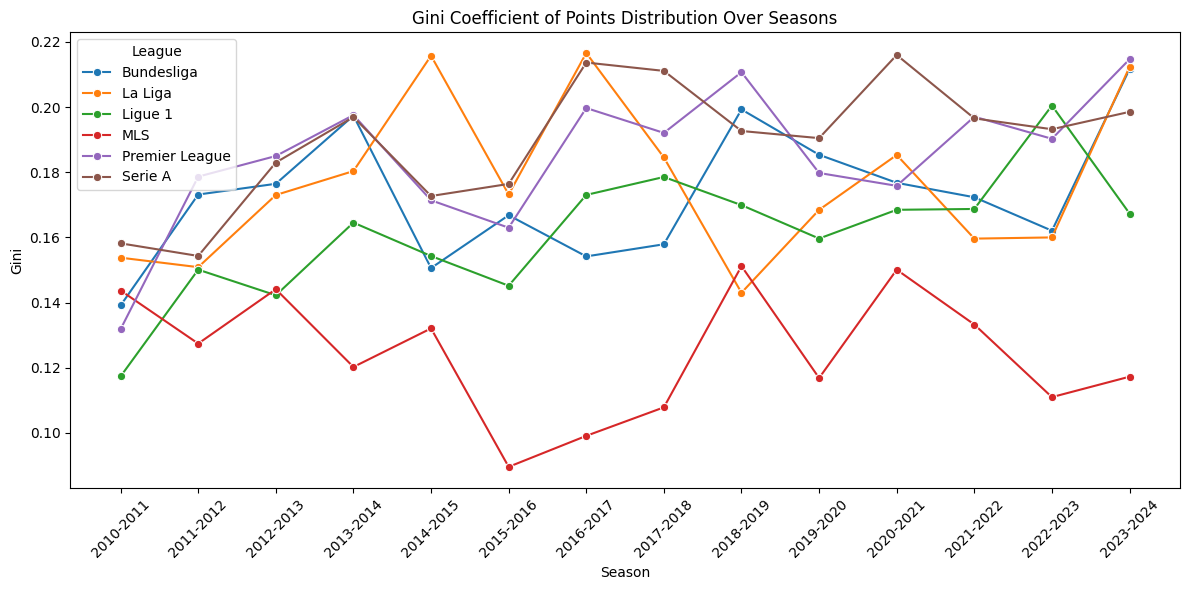

In [9]:
import numpy as np

def gini_coefficient(array):
    """Calculate the Gini coefficient of an array."""
    array = np.array(array, dtype=float)
    if np.amin(array) < 0:
        array -= np.amin(array)  # Shift values to non-negative
    if np.sum(array) == 0:
        return 0.0
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    return (np.sum((2*index - n - 1) * array)) / (n * np.sum(array))

gini_values = standings_df.groupby(["League", "Season"])["Pts"].apply(gini_coefficient).reset_index().rename(columns={"Pts": "Gini"})

plt.figure(figsize=(12, 6))
sns.lineplot(x="Season", y="Gini", hue="League", data=gini_values, marker="o")
plt.title("Gini Coefficient of Points Distribution Over Seasons")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
standings_df[standings_df['League'] == 'MLS'].Notes.unique()

array(['→ Conference Semifinals', nan, '→ Play-in round',
       '→ Knockout round', '→ Round 1', '→ First Round',
       '→ Play-In Round', '→ Round One', '→ Wild Card Round'],
      dtype=object)

In [13]:
standings_df[standings_df['League'] == 'Ligue 1'].Notes.unique()

array(['→ Champions League via league finish',
       '→ Europa League via league finish',
       '→ Europa League via league finish 1',
       '→ Europa League via league finish 2', nan, 'Relegated',
       '→ Europa League via cup win 1', '→ Europa League via cup win 2',
       '2-point deduction 3',
       '→ French 1/2 Relegation/Promotion Playoffs', 'Relegated 3',
       '→ Europa Conference League via league finish',
       '→ French 1/2 Relegation/Promotion Playoff',
       '1-point deduction 1, → Europa Conference League via league finish',
       '1-point deduction 2', '→ Europa League via cup win',
       '→ French 1/2 Relegation/Promotion Play-off',
       '1-point deduction 1'], dtype=object)

## Find High-Level Teams (Make it to European-level games or Play-offs)

In [19]:
# Convert the Notes column to lowercase and strip extra whitespace.
# This makes checking for substrings easier.
standings_df["Notes"] = standings_df["Notes"].astype(str).str.lower().str.strip()

# For European leagues, select rows where 'notes' contains the substring "league".
eu_mask = (standings_df["League"] != "MLS") & (standings_df["Notes"].str.contains("league", na=False))
eu_qualified = standings_df[eu_mask].copy()

# For MLS, select rows where the 'notes' field is not empty.
mls_mask = (standings_df["League"] == "MLS") & (standings_df["Notes"].str.strip() != "nan")
mls_qualified = standings_df[mls_mask].copy()

# Combine the two subsets into one DataFrame.
qualified_df = pd.concat([eu_qualified, mls_qualified], ignore_index=True)

print("Qualified teams (first 10 rows):")
print(qualified_df.head(10))


Qualified teams (first 10 rows):
           League     Season  Rk             Team  MP   W   D   L  GF  GA  GD  \
0  Premier League  2010-2011   1   Manchester Utd  38  23  11   4  78  37  41   
1  Premier League  2010-2011   2          Chelsea  38  21   8   9  69  33  36   
2  Premier League  2010-2011   3  Manchester City  38  21   8   9  60  33  27   
3  Premier League  2010-2011   4          Arsenal  38  19  11   8  72  43  29   
4  Premier League  2010-2011   5        Tottenham  38  16  14   8  55  46   9   
5  Premier League  2010-2011   8           Fulham  38  11  16  11  49  43   6   
6  Premier League  2010-2011  13       Stoke City  38  13   7  18  46  48  -2   
7  Premier League  2010-2011  18  Birmingham City  38   8  15  15  37  58 -21   
8  Premier League  2011-2012   1  Manchester City  38  28   5   5  93  29  64   
9  Premier League  2011-2012   2   Manchester Utd  38  28   5   5  89  33  56   

   Pts  Pts/MP                                   Notes  
0   80    2.11    

In [20]:
qualified_df

,League,Season,Rk,Team,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Notes
0,Premier League,2010-2011,1,Manchester Utd,38,23,11,4,78,37,41,80,2.11,→ champions league via league finish
1,Premier League,2010-2011,2,Chelsea,38,21,8,9,69,33,36,71,1.87,→ champions league via league finish
2,Premier League,2010-2011,3,Manchester City,38,21,8,9,60,33,27,71,1.87,→ champions league via league finish
3,Premier League,2010-2011,4,Arsenal,38,19,11,8,72,43,29,68,1.79,→ champions league via league finish
4,Premier League,2010-2011,5,Tottenham,38,16,14,8,55,46,9,62,1.63,→ europa league via league finish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640,MLS,2023-2024,5,Real Salt Lake,34,14,8,12,48,50,-2,50,1.47,→ round one
641,MLS,2023-2024,6,Vancouver W'caps,34,12,12,10,55,48,7,48,1.41,→ round one
642,MLS,2023-2024,7,FC Dallas,34,11,13,10,41,37,4,46,1.35,→ round one
643,MLS,2023-2024,8,Sporting KC,34,12,8,14,48,51,-3,44,1.29,→ wild card round


In [22]:
# Optionally, save the qualified teams DataFrame to a CSV file.
qualified_df.to_csv("qualified_teams_by_league_season_2010-2024.csv", index=False)

In [23]:
import pandas as pd
import numpy as np

# Define a function to compute the Gini coefficient.
def gini_coefficient(x):
    """Calculate the Gini coefficient of an array of values."""
    # Ensure x is a numpy array
    x = np.array(x, dtype=float)
    if np.amin(x) < 0:
        x -= np.amin(x)  # shift the array so that all values are non-negative
    # Avoid division by zero.
    if np.sum(x) == 0:
        return 0.0
    x = np.sort(x)
    n = x.size
    index = np.arange(1, n + 1)
    # Gini formula: (sum((2*i - n - 1) * x_i)) / (n * sum(x))
    return np.sum((2*index - n - 1) * x) / (n * np.sum(x))

# Optionally, inspect the unique values in the key columns.
print("Unique Leagues:", qualified_df["League"].unique())
print("Unique Seasons:", qualified_df["Season"].unique())

# Group by League and Season, and then compute the standard deviation and Gini coefficient for Points.
competitiveness_metrics = qualified_df.groupby(["League", "Season"])["Pts"].agg(
    pts_std = "std",
    pts_range = lambda x: x.max() - x.min(),
    pts_mean = "mean"
).reset_index()

# Calculate the Gini coefficient for each group.
gini_list = []
for _, group in qualified_df.groupby(["League", "Season"]):
    gini_list.append(gini_coefficient(group["Pts"]))

# The groupby order is the same as above, so add as a new column.
competitiveness_metrics["gini"] = gini_list

# Optionally, you can compute the coefficient of variation (std/mean).
competitiveness_metrics["cv"] = competitiveness_metrics["pts_std"] / competitiveness_metrics["pts_mean"]

print("Competitiveness Metrics:")
print(competitiveness_metrics.head())


Unique Leagues: ['Premier League' 'La Liga' 'Bundesliga' 'Serie A' 'Ligue 1' 'MLS']
Unique Seasons: ['2010-2011' '2011-2012' '2012-2013' '2013-2014' '2014-2015' '2015-2016'
 '2016-2017' '2017-2018' '2018-2019' '2019-2020' '2020-2021' '2021-2022'
 '2022-2023' '2023-2024']
Competitiveness Metrics:
       League     Season    pts_std  pts_range   pts_mean      gini        cv
0  Bundesliga  2010-2011   6.760178         17  65.200000  0.051534  0.103684
1  Bundesliga  2011-2012  11.767591         33  61.857143  0.098317  0.190238
2  Bundesliga  2012-2013  15.797830         48  60.285714  0.127285  0.262049
3  Bundesliga  2013-2014  12.562226         37  64.857143  0.092511  0.193691
4  Bundesliga  2014-2015  12.512851         33  59.714286  0.107997  0.209545


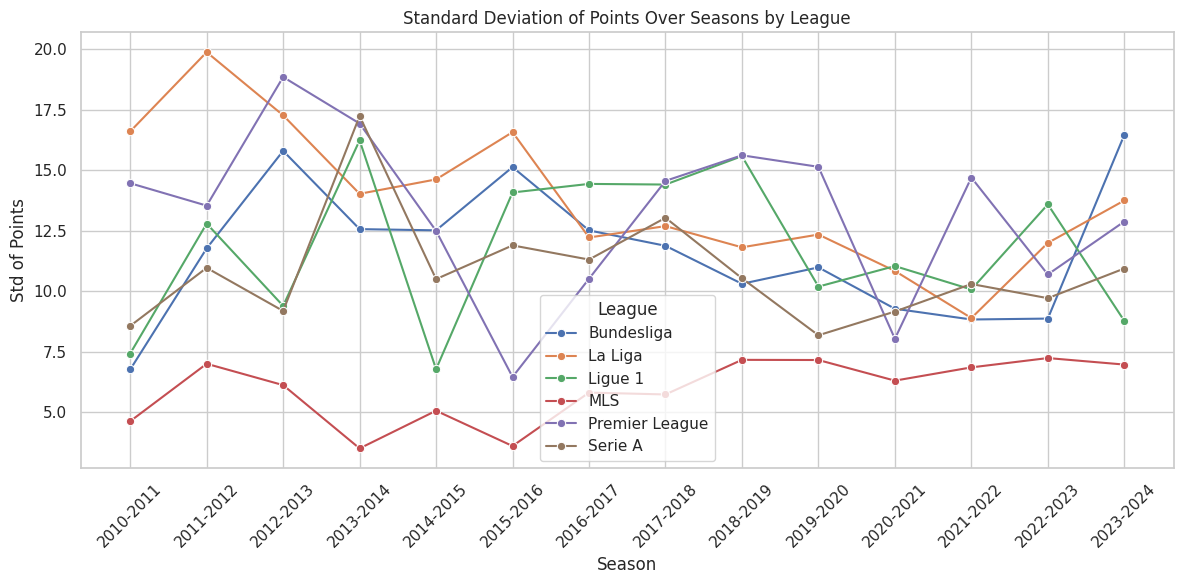

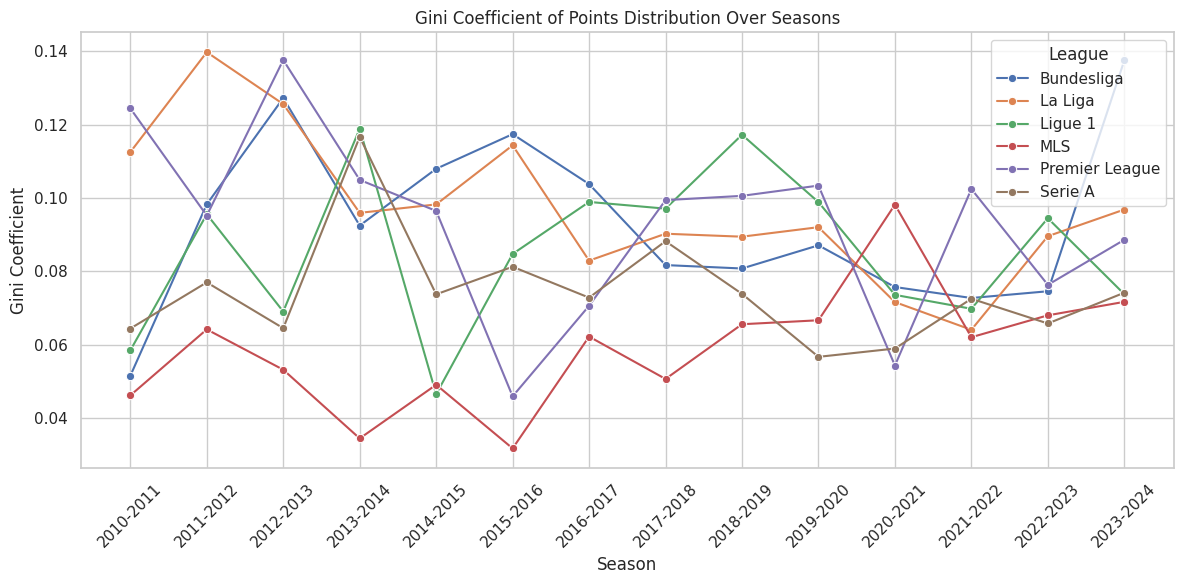

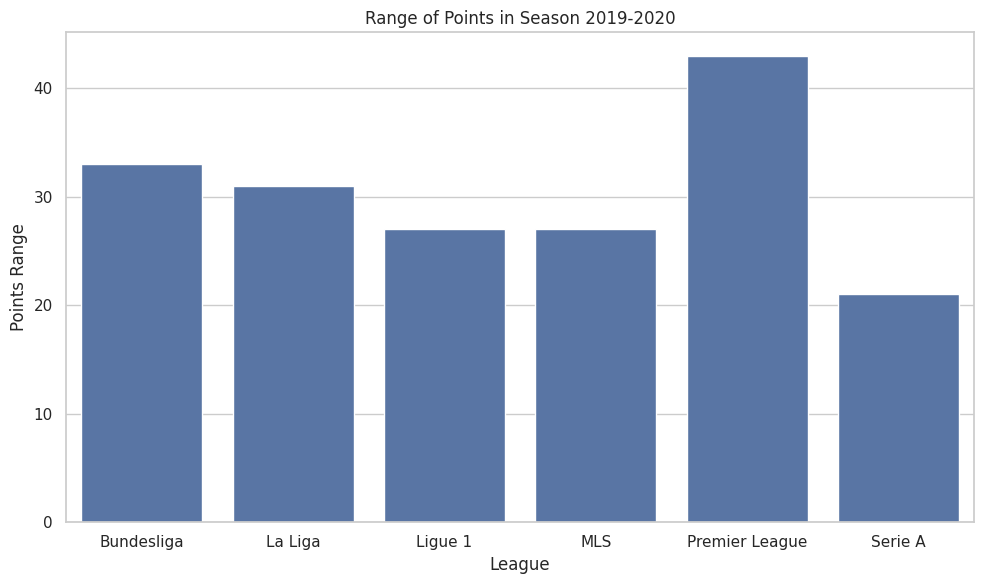

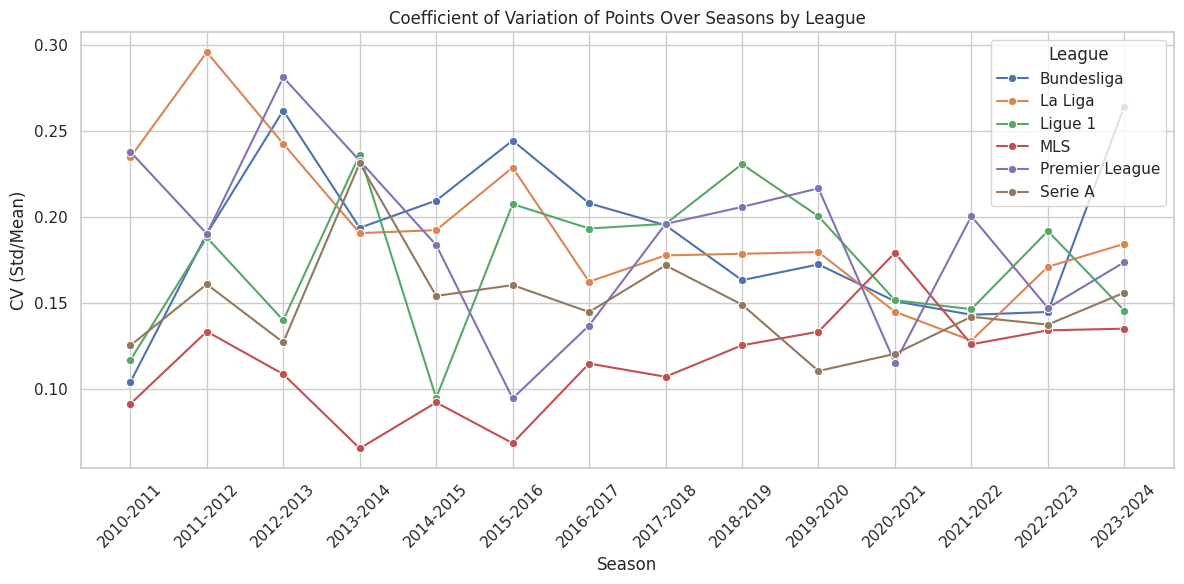

In [24]:
# It might be helpful to ensure 'Season' is treated as an ordered categorical variable.
# For example, if seasons are like "2010-2011", "2011-2012", etc. you can do:
seasons_order = sorted(competitiveness_metrics["Season"].unique())
competitiveness_metrics["Season"] = pd.Categorical(competitiveness_metrics["Season"], categories=seasons_order, ordered=True)

# Set a Seaborn style
sns.set(style="whitegrid")

# -------------------------------
# Plot 1: Standard Deviation of Points Over Seasons
# -------------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(data=competitiveness_metrics, x="Season", y="pts_std", hue="League", marker="o")
plt.title("Standard Deviation of Points Over Seasons by League")
plt.xticks(rotation=45)
plt.ylabel("Std of Points")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

# -------------------------------
# Plot 2: Gini Coefficient Over Seasons
# -------------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(data=competitiveness_metrics, x="Season", y="gini", hue="League", marker="o")
plt.title("Gini Coefficient of Points Distribution Over Seasons")
plt.xticks(rotation=45)
plt.ylabel("Gini Coefficient")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

# -------------------------------
# Plot 3: Range of Points by League (for a selected season)
# -------------------------------
# For example, select season "2019-2020" or any season of interest.
selected_season = "2019-2020"
range_df = competitiveness_metrics[competitiveness_metrics["Season"] == selected_season]

plt.figure(figsize=(10, 6))
sns.barplot(data=range_df, x="League", y="pts_range")
plt.title(f"Range of Points in Season {selected_season}")
plt.ylabel("Points Range")
plt.xlabel("League")
plt.tight_layout()
plt.show()

# -------------------------------
# Plot 4: Coefficient of Variation of Points Over Seasons (Optional)
# -------------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(data=competitiveness_metrics, x="Season", y="cv", hue="League", marker="o")
plt.title("Coefficient of Variation of Points Over Seasons by League")
plt.xticks(rotation=45)
plt.ylabel("CV (Std/Mean)")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

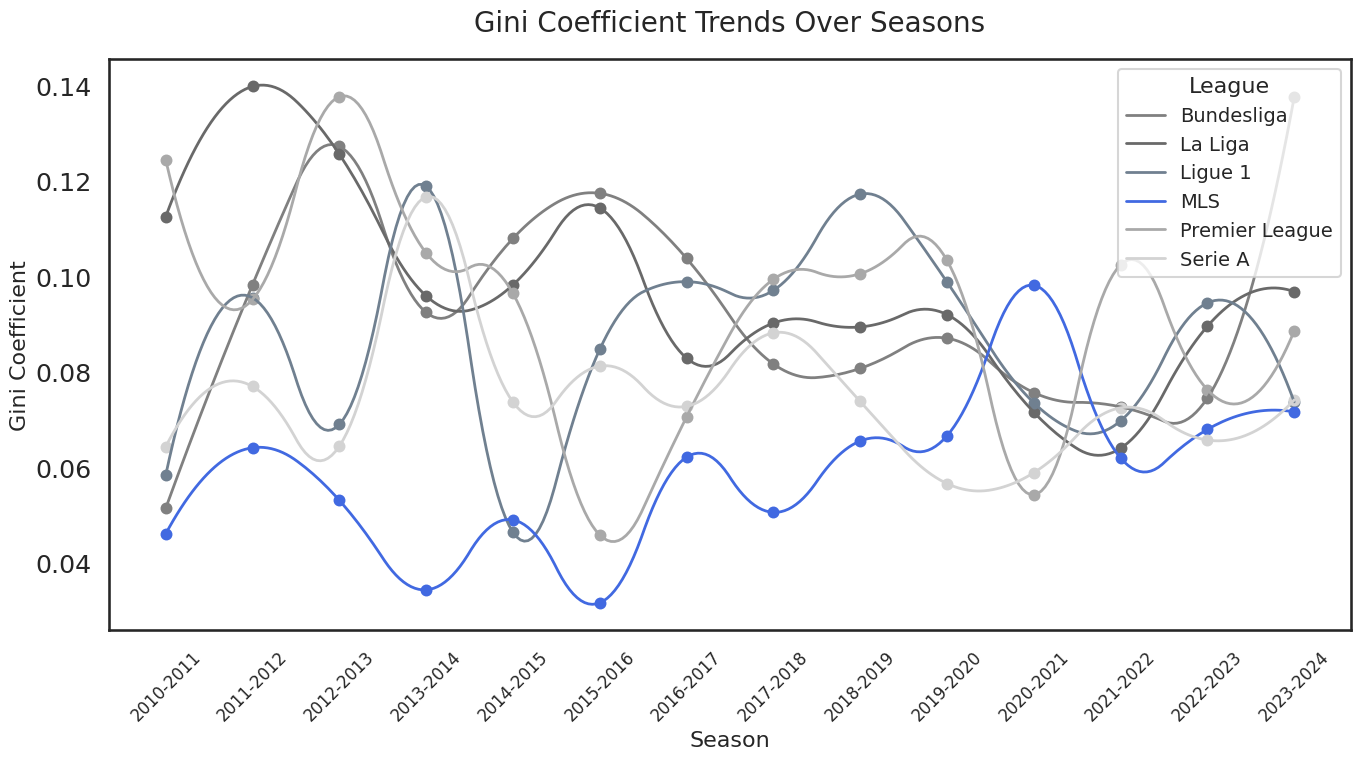

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

# Example: 'competitiveness_metrics' DataFrame with columns:
# ["League", "Season", "gini", ...]

# Ensure 'Season' is ordered properly
seasons_order = sorted(competitiveness_metrics["Season"].unique())
competitiveness_metrics["Season"] = pd.Categorical(competitiveness_metrics["Season"],
                                                   categories=seasons_order, ordered=True)

# Map season labels to numeric values for interpolation
season_mapping = {season: idx for idx, season in enumerate(seasons_order)}
competitiveness_metrics["Season_Num"] = competitiveness_metrics["Season"].map(season_mapping)

# Define a custom palette giving MLS a standout color
custom_palette = {
    "BUNDESLIGA": "gray",
    "LA LIGA": "dimgray",
    "LIGUE 1": "slategray",
    "PREMIER LEAGUE": "darkgray",
    "SERIE A": "lightgray",
    "MLS": "royalblue"
}

# --- Key change: Use a style without grid lines ---
sns.set_style("white")  # or "ticks" or "dark" if you prefer

# We can still use a similar context, e.g., 'talk'
sns.set_context("talk", font_scale=1.1)

plt.figure(figsize=(14, 8))

for league, grp in competitiveness_metrics.groupby("League"):
    grp = grp.sort_values("Season_Num")
    x = grp["Season_Num"].values
    y = grp["gini"].values

    if len(x) > 3:  # Cubic spline if we have enough data points
        x_new = np.linspace(x.min(), x.max(), 300)
        spline = make_interp_spline(x, y, k=2)
        y_smooth = spline(x_new)
    else:
        x_new, y_smooth = x, y

    color = custom_palette.get(league.upper(), "gray")

    # Plot the smooth line
    plt.plot(x_new, y_smooth, label=league, color=color, linewidth=2)
    # Plot the original points
    plt.scatter(x, y, color=color, s=50)

# Set custom x-ticks to correspond to your season labels
plt.xticks([season_mapping[s] for s in seasons_order], seasons_order, rotation=45, fontsize=12)
plt.ylabel("Gini Coefficient", fontsize=16)
plt.xlabel("Season", fontsize=16)
plt.title("Gini Coefficient Trends Over Seasons", fontsize=20, pad=20)

plt.legend(title="League", title_fontsize=16, fontsize=14, loc="upper right")

plt.tight_layout()
plt.show()

# Fixtures Data Deep Analysis

In [33]:
fixtures_df = pd.read_csv('data/final_merged_fixtures_2010-2024.csv')
fixtures_df

,league,season,team,avg_scored_home,avg_conceded_home,home_win_pct,home_close_match_pct,avg_scored_away,avg_conceded_away,away_win_pct,away_close_match_pct,overall_avg_conceded,players_used,avg_age,goals,goals_per90,assists,assists_per90,goals_and_assists,goals_and_assists_per90,goals_excluding_pk,goals_excluding_pk_per90,penalty_kicks,penalty_attempts,yellow_cards,red_cards,goals_and_assists_excl_pk
0,Bundesliga,2010-2011,BAYERN MUNICH,2.82,0.76,76.47,23.53,1.94,1.59,35.29,17.65,1.18,24,26.5,77,2.26,54,1.59,131,3.85,74,2.18,3,6,43,2.0,3.76
1,Bundesliga,2010-2011,DORTMUND,2.06,0.47,70.59,5.88,1.88,0.82,64.71,29.41,0.65,23,23.4,63,1.85,42,1.24,105,3.09,63,1.85,0,3,41,1.0,3.09
2,Bundesliga,2010-2011,EINT FRANKFURT,0.76,1.41,29.41,29.41,1.06,1.47,23.53,41.18,1.44,27,26.2,31,0.91,20,0.59,51,1.50,27,0.79,4,4,75,3.0,1.38
3,Bundesliga,2010-2011,FREIBURG,1.41,1.41,47.06,64.71,1.00,1.53,29.41,52.94,1.47,27,25.5,38,1.12,21,0.62,59,1.74,34,1.00,4,6,48,3.0,1.62
4,Bundesliga,2010-2011,GLADBACH,1.53,1.82,29.41,47.06,1.29,2.00,29.41,41.18,1.91,28,25.8,47,1.38,29,0.85,76,2.24,43,1.26,4,4,56,8.0,2.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1675,Serie A,2023-2024,ROMA,2.00,1.00,63.16,42.11,1.42,1.42,31.58,42.11,1.21,30,27.7,64,1.68,44,1.16,108,2.84,53,1.39,11,12,95,3.0,2.55
1676,Serie A,2023-2024,SALERNITANA,0.89,2.00,5.26,42.11,0.79,2.26,5.26,21.05,2.13,39,27.2,32,0.84,25,0.66,57,1.50,30,0.79,2,2,91,3.0,1.45
1677,Serie A,2023-2024,SASSUOLO,1.21,1.79,26.32,36.84,1.05,2.16,10.53,47.37,1.97,30,26.4,42,1.11,28,0.74,70,1.84,35,0.92,7,8,71,4.0,1.66
1678,Serie A,2023-2024,TORINO,0.95,0.47,42.11,21.05,0.95,1.42,26.32,31.58,0.95,30,26.4,35,0.92,29,0.76,64,1.68,33,0.87,2,2,75,2.0,1.63


In [35]:
fixtures_df.dtypes

,0
league,object
season,object
team,object
avg_scored_home,float64
avg_conceded_home,float64
home_win_pct,float64
home_close_match_pct,float64
avg_scored_away,float64
avg_conceded_away,float64
away_win_pct,float64


## Logistic Regression (All-level Team)

In [60]:
# ----- Step 1: Create Binary Outcome Variable -----
# Target: which league family a team-season belongs to. 1 = one of Europe's big five, 0 = MLS.
# This is league IDENTITY, not league quality -- the label says where a team plays, not how good it is.
# and MLS is not (label 0). Adjust matching as needed (e.g., uppercase comparison).
fixtures_df["is_european"] = fixtures_df["league"].apply(lambda x: 0 if str(x).strip().upper() == "MLS" else 1)

# ----- Step 2: Define Feature Columns -----
# If your keys (non-numeric columns) are "League", "Season", and "Team", we want to exclude these.
# We want to include all remaining numeric columns.
non_feature_columns = ["league", "season", "team", "is_european"]

# Select only numeric columns from the dataframe:
numeric_cols = fixtures_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Option 1: If all numeric columns are features, then use those.
feature_columns = [col for col in numeric_cols if col not in non_feature_columns]

# Option 2: If you want to check manually, print out the numeric columns and decide which to keep.
print("Numeric columns available:", numeric_cols)
print("Feature columns used:", feature_columns)

# ----- Verification: Display Sample of Data with Features and Outcome -----
print("Sample Data:")
fixtures_df[["league", "season", "team", "is_european"] + feature_columns].head()

# Create the modeling dataframe: drop rows with NaNs in feature or target columns.
model_df = fixtures_df.dropna(subset=feature_columns + ["is_european"]).copy()

# Separate predictors (X) and target (y)
X = model_df[feature_columns]
y = model_df["is_european"]

Numeric columns available: ['avg_scored_home', 'avg_conceded_home', 'home_win_pct', 'home_close_match_pct', 'avg_scored_away', 'avg_conceded_away', 'away_win_pct', 'away_close_match_pct', 'overall_avg_conceded', 'players_used', 'avg_age', 'goals', 'goals_per90', 'assists', 'assists_per90', 'goals_and_assists', 'goals_and_assists_per90', 'goals_excluding_pk', 'goals_excluding_pk_per90', 'penalty_kicks', 'penalty_attempts', 'yellow_cards', 'red_cards', 'goals_and_assists_excl_pk', 'competitive']
Feature columns used: ['avg_scored_home', 'avg_conceded_home', 'home_win_pct', 'home_close_match_pct', 'avg_scored_away', 'avg_conceded_away', 'away_win_pct', 'away_close_match_pct', 'overall_avg_conceded', 'players_used', 'avg_age', 'goals', 'goals_per90', 'assists', 'assists_per90', 'goals_and_assists', 'goals_and_assists_per90', 'goals_excluding_pk', 'goals_excluding_pk_per90', 'penalty_kicks', 'penalty_attempts', 'yellow_cards', 'red_cards', 'goals_and_assists_excl_pk']
Sample Data:


In [66]:
# ----- Step 2: Feature Selection with RFECV Using Logistic Regression -----
# We use StratifiedKFold to preserve the proportion of classes in each fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=5000, random_state=42)
rfecv = RFECV(estimator=lr, step=1, cv=cv, scoring="accuracy")
rfecv.fit(X, y)

print("Optimal number of features:", rfecv.n_features_)
# Build the list of selected features using a list comprehension.
selected_features = [feature_columns[i] for i, selected in enumerate(rfecv.support_) if selected]
print("Selected features:", selected_features)

# Reduce X to the selected features using .iloc.
X_selected = X.iloc[:, rfecv.support_]

Optimal number of features: 24
Selected features: ['avg_scored_home', 'avg_conceded_home', 'home_win_pct', 'home_close_match_pct', 'avg_scored_away', 'avg_conceded_away', 'away_win_pct', 'away_close_match_pct', 'overall_avg_conceded', 'players_used', 'avg_age', 'goals', 'goals_per90', 'assists', 'assists_per90', 'goals_and_assists', 'goals_and_assists_per90', 'goals_excluding_pk', 'goals_excluding_pk_per90', 'penalty_kicks', 'penalty_attempts', 'yellow_cards', 'red_cards', 'goals_and_assists_excl_pk']


In [68]:
# ----- Step 3: Evaluate Logistic Regression with Cross-Validation (scikit‑learn) -----
cv_scores = cross_val_score(lr, X_selected, y, cv=cv, scoring="accuracy")
print("Logistic Regression Cross-Validated Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))

# Fit the model on the entire dataset (with selected features) to interpret coefficients (scikit‑learn)
lr.fit(X_selected, y)
coeff_df = pd.DataFrame({"Feature": selected_features, "Coefficient": lr.coef_[0]})
print("Logistic Regression Coefficients (scikit‑learn):")
print(coeff_df)

# Optionally, save the selected features and model evaluation results
model_results = {
    "optimal_features": selected_features,
    "cv_accuracy": np.mean(cv_scores)
}

Logistic Regression Cross-Validated Accuracy: 90.33%
Logistic Regression Coefficients (scikit‑learn):
                      Feature  Coefficient
0             avg_scored_home    -2.017278
1           avg_conceded_home     0.761730
2                home_win_pct     0.000221
3        home_close_match_pct    -0.027615
4             avg_scored_away    -0.972622
5           avg_conceded_away    -0.423284
6                away_win_pct     0.053058
7        away_close_match_pct    -0.037686
8        overall_avg_conceded     0.104836
9                players_used    -0.028764
10                    avg_age    -0.402642
11                      goals     0.091220
12                goals_per90    -1.742261
13                    assists     0.011247
14              assists_per90    -1.038825
15          goals_and_assists     0.102468
16    goals_and_assists_per90    -2.715068
17         goals_excluding_pk     0.156836
18   goals_excluding_pk_per90    -1.552189
19              penalty_kicks    -0.06

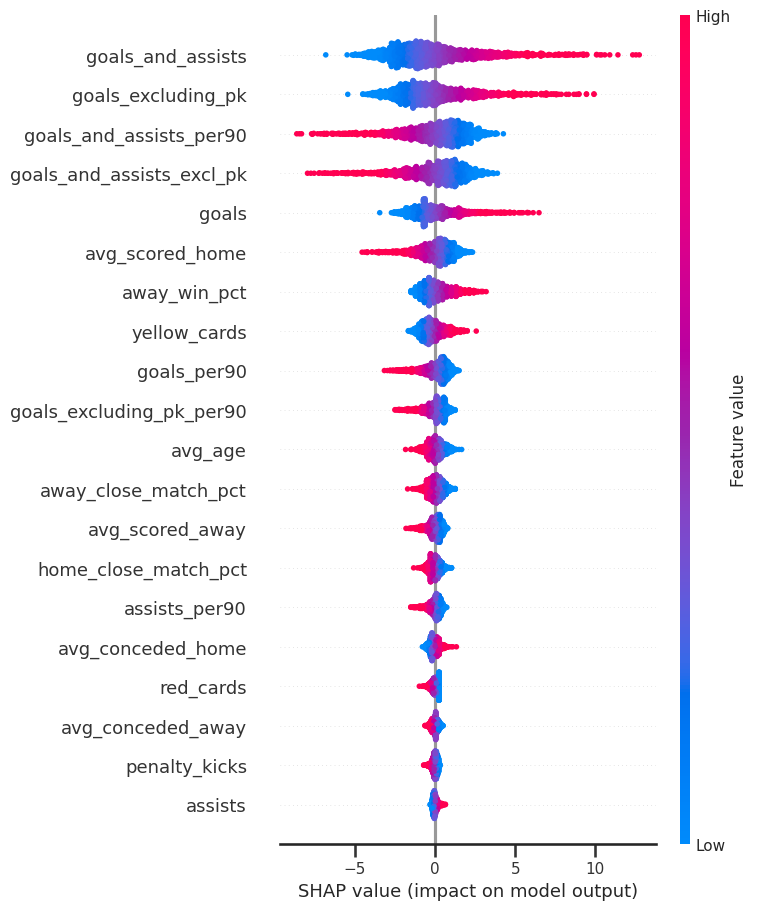

In [69]:
import shap

explainer = shap.LinearExplainer(lr, X_selected)
shap_values = explainer.shap_values(X_selected)
shap.summary_plot(shap_values, X_selected, feature_names=selected_features)

In [70]:
# ----- Step 5: Generate a Detailed Logistic Regression Summary using statsmodels -----
# Convert X_selected (a DataFrame) to a new DataFrame (already in original units).
X_selected_df = X_selected.copy().reset_index(drop=True)
y_reset = pd.Series(y).reset_index(drop=True)

# Add a constant to include an intercept.
X_selected_df = sm.add_constant(X_selected_df)

# Fit the logistic regression model using statsmodels.
logit_model = sm.Logit(y_reset, X_selected_df)
result = logit_model.fit(disp=False)  # disp=False suppresses iterative output

# Print the detailed summary table.
print(result.summary())


                           Logit Regression Results                           
Dep. Variable:            competitive   No. Observations:                 1510
Model:                          Logit   Df Residuals:                     1485
Method:                           MLE   Df Model:                           24
Date:                Tue, 08 Apr 2025   Pseudo R-squ.:                  0.4714
Time:                        09:01:15   Log-Likelihood:                -328.58
converged:                      False   LL-Null:                       -621.57
Covariance Type:            nonrobust   LLR p-value:                2.025e-108
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        15.6014      2.861      5.454      0.000       9.995      21.208
avg_scored_home              -2.0210      1.566     -1.291      0.197      -5.090     

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


##Decision Tree (All-level Team)

Effective ccp_alphas: [0.         0.00043752 0.00061131 0.0006274  0.00063346 0.00064277
 0.00064277 0.00064577 0.00064901 0.00065157 0.00065795 0.000883
 0.000883   0.00091839 0.00099338 0.00099338 0.00099338 0.00104571
 0.0010596  0.00107616 0.00110375 0.00110375 0.00110375 0.00113529
 0.00117734 0.00119205 0.00119836 0.00120297 0.00120409 0.00121413
 0.00122965 0.00123545 0.0012362  0.00125092 0.0012772  0.00128358
 0.0013166  0.00135846 0.00140492 0.0014128  0.00145036 0.00155445
 0.0015894  0.00172185 0.00196582 0.00206034 0.00208015 0.00211921
 0.00214258 0.00220751 0.00225038 0.00228604 0.00231654 0.00243177
 0.00250497 0.00254539 0.00266154 0.00273269 0.00277919 0.00313917
 0.00354082 0.00373901 0.003776   0.00419021 0.00528043 0.00532684
 0.00595734 0.00818162 0.01181982 0.02279645]


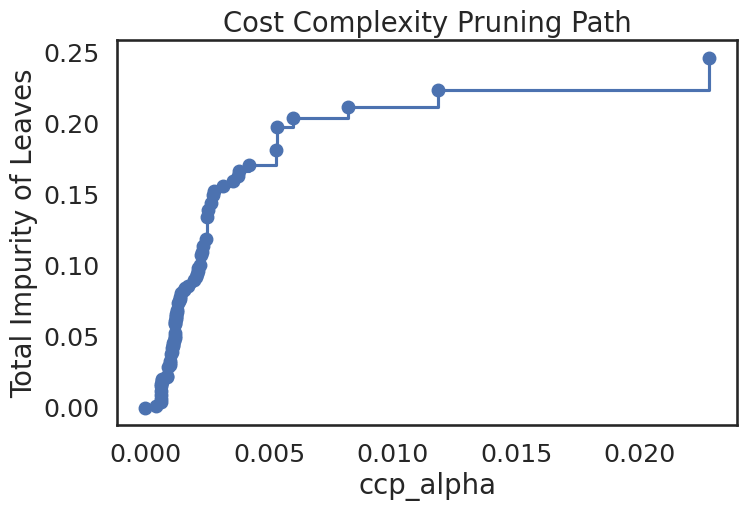

Best ccp_alpha: 0.0031391677941560465
Best cross-validated accuracy: 86.16%


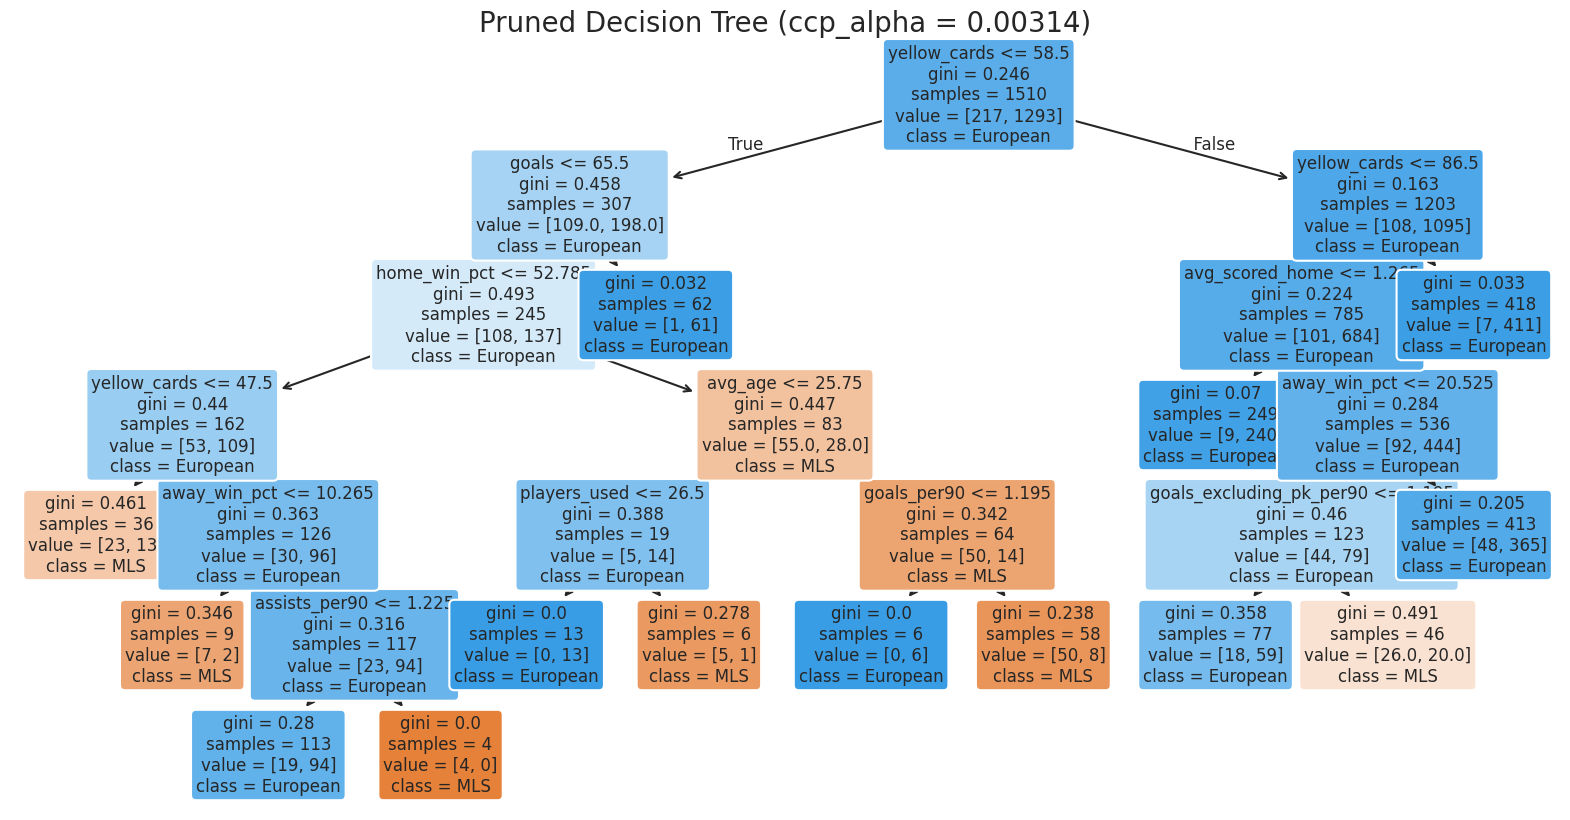

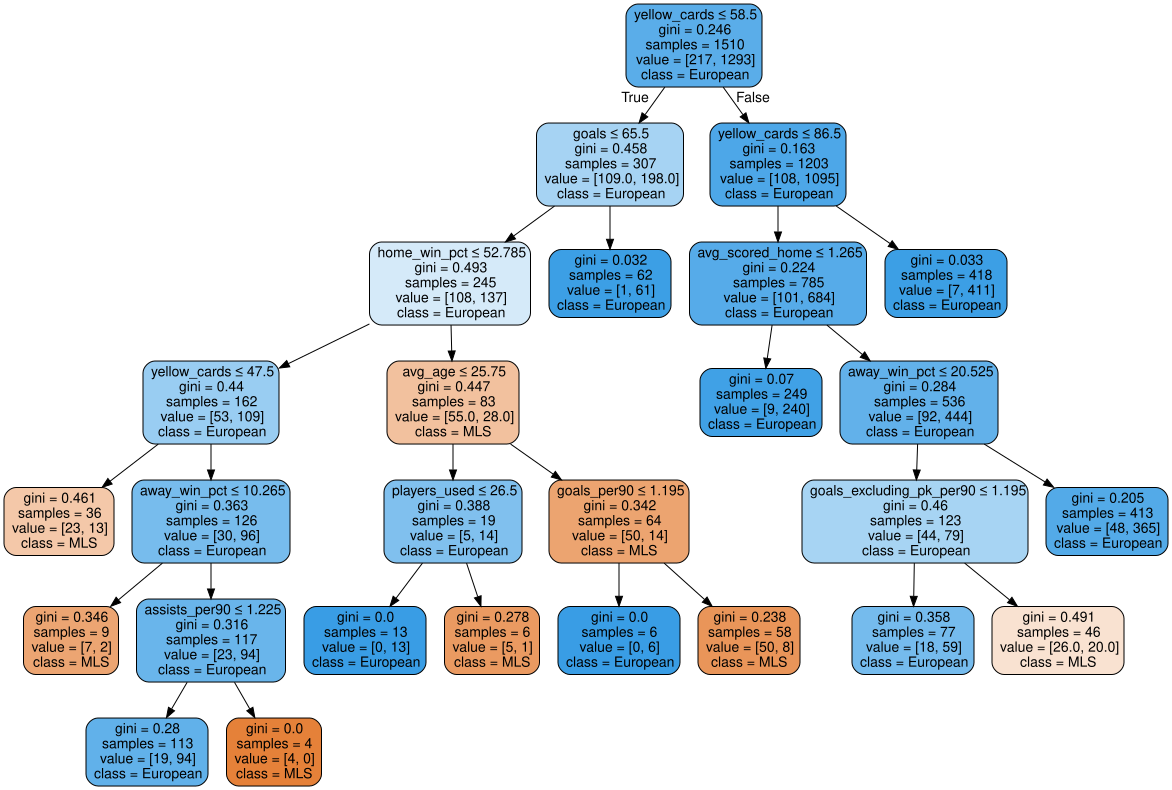

In [73]:
# ----- Step 1: Load and Preprocess the Data -----

# Drop rows with missing values in the features or outcome.
df_model = fixtures_df.dropna(subset=feature_columns + ["is_european"]).copy()

# Separate predictors and target
X = df_model[feature_columns]
y = df_model["is_european"]


# --- Step 1: Grow a Full Decision Tree with Gini Criterion ---
# Initialize the Decision Tree with Gini as the splitting criterion.
dt_full = DecisionTreeClassifier(random_state=42, criterion="gini")
dt_full.fit(X, y)

# --- Step 2: Obtain the Cost Complexity Pruning Path ---
# This function returns effective alphas and the corresponding total impurity of leaves.
path = dt_full.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Effective ccp_alphas:", ccp_alphas)

# Plot the relationship between ccp_alpha and impurity (optional)
plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
plt.title("Cost Complexity Pruning Path")
plt.xlabel("ccp_alpha")
plt.ylabel("Total Impurity of Leaves")
plt.show()

# --- Step 3: Use Cross-Validation to Find Optimal ccp_alpha ---
# Prepare a grid of candidate ccp_alpha values.
param_grid = {'ccp_alpha': ccp_alphas}

# Initialize a new Decision Tree using the Gini criterion.
dt = DecisionTreeClassifier(random_state=42, criterion="gini")

# Use StratifiedKFold for CV.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=cv, scoring="accuracy")
grid_search.fit(X, y)

print("Best ccp_alpha:", grid_search.best_params_['ccp_alpha'])
print("Best cross-validated accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

# --- Step 4: Train a Pruned Decision Tree ---
optimal_alpha = grid_search.best_params_['ccp_alpha']
dt_pruned = DecisionTreeClassifier(random_state=42, criterion="gini", ccp_alpha=optimal_alpha)
dt_pruned.fit(X, y)

# Optionally, visualize the pruned tree using plot_tree:
plt.figure(figsize=(20, 10))
plot_tree(dt_pruned, feature_names=feature_columns, class_names=["MLS", "European"], filled=True, rounded=True, fontsize=12)
plt.title("Pruned Decision Tree (ccp_alpha = {:.5f})".format(optimal_alpha))
plt.show()

# Optionally, export the tree to Graphviz for a cleaner visualization:
from sklearn.tree import export_graphviz
dot_data = export_graphviz(dt_pruned,
                           out_file=None,
                           feature_names=feature_columns,
                           class_names=["MLS", "European"],
                           filled=True, rounded=True,
                           special_characters=True)
import graphviz
graph = graphviz.Source(dot_data)
graph.render("pruned_decision_tree", format="png")
graph  # in Jupyter Notebook, this displays the image

## Logistic Regression (Qualified Team)

In [77]:
# ----- Step 2: Standardize Key Columns -----
# It is important to standardize the keys (e.g., League, Season, Team) in both datasets before merging.
qualified_df.columns = [col.lower() for col in qualified_df.columns]

def standardize_keys(df):
    df["league"] = df["league"].str.upper().str.strip()
    df["team"] = df["team"].str.upper().str.strip()
    df["season"] = df["season"].str.strip()
    return df

qualified_df = standardize_keys(qualified_df)
fixtures_df = standardize_keys(fixtures_df)

# ----- Step 3: Filter Fixtures to Only Include Qualified Teams -----
# Since qualified_df contains the team-season combinations for high-quality teams, we can merge on these keys.
# We use an inner join so that only fixtures matching a qualified team (by League, Season, Team) are kept.
qualified_fixtures_df = fixtures_df.merge(qualified_df[['league', 'season', 'team']],
                                           on=['league', 'season', 'team'],
                                           how='inner')

print("Number of fixtures for qualified teams:", qualified_fixtures_df.shape[0])
print("Sample of qualified fixtures data:")
qualified_fixtures_df.head()

Number of fixtures for qualified teams: 645
Sample of qualified fixtures data:


,league,season,team,avg_scored_home,avg_conceded_home,home_win_pct,home_close_match_pct,avg_scored_away,avg_conceded_away,away_win_pct,away_close_match_pct,overall_avg_conceded,players_used,avg_age,goals,goals_per90,assists,assists_per90,goals_and_assists,goals_and_assists_per90,goals_excluding_pk,goals_excluding_pk_per90,penalty_kicks,penalty_attempts,yellow_cards,red_cards,goals_and_assists_excl_pk,competitive
0,BUNDESLIGA,2010-2011,BAYERN MUNICH,2.82,0.76,76.47,23.53,1.94,1.59,35.29,17.65,1.18,24,26.5,77,2.26,54,1.59,131,3.85,74,2.18,3,6,43,2.0,3.76,1
1,BUNDESLIGA,2010-2011,DORTMUND,2.06,0.47,70.59,5.88,1.88,0.82,64.71,29.41,0.65,23,23.4,63,1.85,42,1.24,105,3.09,63,1.85,0,3,41,1.0,3.09,1
2,BUNDESLIGA,2010-2011,HANNOVER 96,1.88,1.00,70.59,47.06,1.00,1.65,41.18,35.29,1.32,23,25.6,48,1.41,30,0.88,78,2.29,45,1.32,3,3,60,5.0,2.21,1
3,BUNDESLIGA,2010-2011,LEVERKUSEN,1.94,1.41,52.94,29.41,1.82,1.18,64.71,41.18,1.29,21,25.2,62,1.82,39,1.15,101,2.97,56,1.65,6,6,57,1.0,2.79,1
4,BUNDESLIGA,2010-2011,MAINZ 05,1.29,0.94,47.06,47.06,1.76,1.35,58.82,52.94,1.15,26,26.1,49,1.44,37,1.09,86,2.53,46,1.35,3,5,54,1.0,2.44,1


In [78]:
# ----- Step 1: Create Binary Outcome Variable -----
# Target: which league family a team-season belongs to. 1 = one of Europe's big five, 0 = MLS.
# This is league IDENTITY, not league quality -- the label says where a team plays, not how good it is.
# and MLS is not (label 0). Adjust matching as needed (e.g., uppercase comparison).
qualified_fixtures_df["is_european"] = qualified_fixtures_df["league"].apply(lambda x: 0 if str(x).strip().upper() == "MLS" else 1)

# ----- Step 2: Define Feature Columns -----
# If your keys (non-numeric columns) are "League", "Season", and "Team", we want to exclude these.
# We want to include all remaining numeric columns.
non_feature_columns = ["league", "season", "team", "is_european"]

# Select only numeric columns from the dataframe:
numeric_cols = qualified_fixtures_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Option 1: If all numeric columns are features, then use those.
feature_columns = [col for col in numeric_cols if col not in non_feature_columns]

# Option 2: If you want to check manually, print out the numeric columns and decide which to keep.
print("Numeric columns available:", numeric_cols)
print("Feature columns used:", feature_columns)

# ----- Verification: Display Sample of Data with Features and Outcome -----
print("Sample Data:")
qualified_fixtures_df[["league", "season", "team", "is_european"] + feature_columns].head()

# Create the modeling dataframe: drop rows with NaNs in feature or target columns.
model_df = qualified_fixtures_df.dropna(subset=feature_columns + ["is_european"]).copy()

# Separate predictors (X) and target (y)
X = model_df[feature_columns]
y = model_df["is_european"]



Numeric columns available: ['avg_scored_home', 'avg_conceded_home', 'home_win_pct', 'home_close_match_pct', 'avg_scored_away', 'avg_conceded_away', 'away_win_pct', 'away_close_match_pct', 'overall_avg_conceded', 'players_used', 'avg_age', 'goals', 'goals_per90', 'assists', 'assists_per90', 'goals_and_assists', 'goals_and_assists_per90', 'goals_excluding_pk', 'goals_excluding_pk_per90', 'penalty_kicks', 'penalty_attempts', 'yellow_cards', 'red_cards', 'goals_and_assists_excl_pk', 'competitive']
Feature columns used: ['avg_scored_home', 'avg_conceded_home', 'home_win_pct', 'home_close_match_pct', 'avg_scored_away', 'avg_conceded_away', 'away_win_pct', 'away_close_match_pct', 'overall_avg_conceded', 'players_used', 'avg_age', 'goals', 'goals_per90', 'assists', 'assists_per90', 'goals_and_assists', 'goals_and_assists_per90', 'goals_excluding_pk', 'goals_excluding_pk_per90', 'penalty_kicks', 'penalty_attempts', 'yellow_cards', 'red_cards', 'goals_and_assists_excl_pk']
Sample Data:


In [79]:
# ----- Step 2: Feature Selection with RFECV Using Logistic Regression -----
# We use StratifiedKFold to preserve the proportion of classes in each fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=5000, random_state=42)
rfecv = RFECV(estimator=lr, step=1, cv=cv, scoring="accuracy")
rfecv.fit(X, y)

print("Optimal number of features:", rfecv.n_features_)
# Build the list of selected features using a list comprehension.
selected_features = [feature_columns[i] for i, selected in enumerate(rfecv.support_) if selected]
print("Selected features:", selected_features)

# Reduce X to the selected features using .iloc.
X_selected = X.iloc[:, rfecv.support_]

Optimal number of features: 13
Selected features: ['avg_scored_home', 'avg_conceded_home', 'avg_scored_away', 'avg_conceded_away', 'overall_avg_conceded', 'avg_age', 'goals', 'goals_per90', 'assists_per90', 'goals_and_assists_per90', 'goals_excluding_pk', 'goals_excluding_pk_per90', 'goals_and_assists_excl_pk']


In [80]:
# ----- Step 3: Evaluate Logistic Regression with Cross-Validation (scikit‑learn) -----
cv_scores = cross_val_score(lr, X_selected, y, cv=cv, scoring="accuracy")
print("Logistic Regression Cross-Validated Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))

# Fit the model on the entire dataset (with selected features) to interpret coefficients (scikit‑learn)
lr.fit(X_selected, y)
coeff_df = pd.DataFrame({"Feature": selected_features, "Coefficient": lr.coef_[0]})
print("Logistic Regression Coefficients (scikit‑learn):")
print(coeff_df)

# Optionally, save the selected features and model evaluation results
model_results = {
    "optimal_features": selected_features,
    "cv_accuracy": np.mean(cv_scores)
}

Logistic Regression Cross-Validated Accuracy: 88.28%
Logistic Regression Coefficients (scikit‑learn):
                      Feature  Coefficient
0             avg_scored_home    -2.093921
1           avg_conceded_home     0.519978
2             avg_scored_away    -0.453162
3           avg_conceded_away    -1.301983
4        overall_avg_conceded    -0.432483
5                     avg_age    -0.492387
6                       goals     0.229328
7                 goals_per90    -1.595701
8               assists_per90    -0.333781
9     goals_and_assists_per90    -1.938428
10         goals_excluding_pk     0.199112
11   goals_excluding_pk_per90    -1.467399
12  goals_and_assists_excl_pk    -1.822884


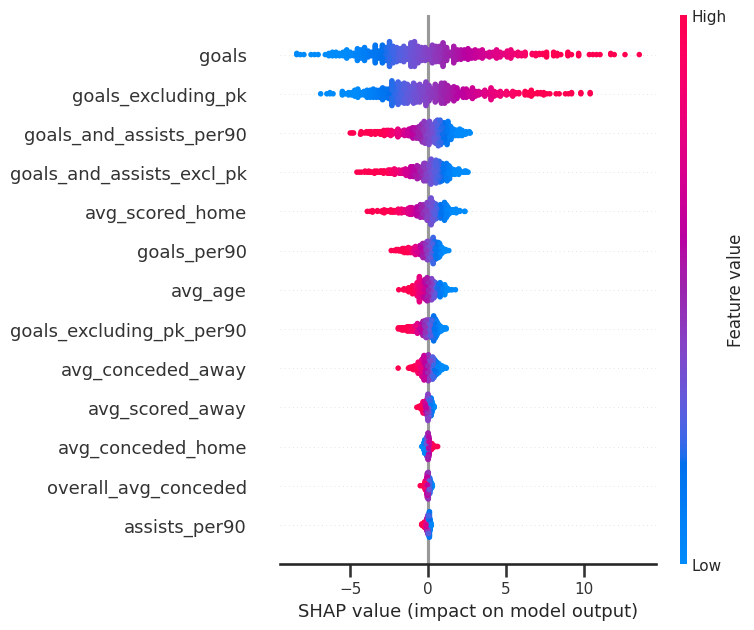

In [81]:
import shap

explainer = shap.LinearExplainer(lr, X_selected)
shap_values = explainer.shap_values(X_selected)
shap.summary_plot(shap_values, X_selected, feature_names=selected_features)

In [82]:
# ----- Step 5: Generate a Detailed Logistic Regression Summary using statsmodels -----
# Convert X_selected (a DataFrame) to a new DataFrame (already in original units).
X_selected_df = X_selected.copy().reset_index(drop=True)
y_reset = pd.Series(y).reset_index(drop=True)

# Add a constant to include an intercept.
X_selected_df = sm.add_constant(X_selected_df)

# Fit the logistic regression model using statsmodels.
logit_model = sm.Logit(y_reset, X_selected_df)
result = logit_model.fit(disp=False)  # disp=False suppresses iterative output

# Print the detailed summary table.
print(result.summary())


                           Logit Regression Results                           
Dep. Variable:            competitive   No. Observations:                  563
Model:                          Logit   Df Residuals:                      549
Method:                           MLE   Df Model:                           13
Date:                Tue, 08 Apr 2025   Pseudo R-squ.:                  0.5436
Time:                        09:28:05   Log-Likelihood:                -132.52
converged:                       True   LL-Null:                       -290.37
Covariance Type:            nonrobust   LLR p-value:                 1.232e-59
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        15.9766      3.909      4.088      0.000       8.316      23.637
avg_scored_home              -0.1445      2.197     -0.066      0.948      -4.450     

## Decision Tree (Qualified Team)

Effective ccp_alphas: [0.         0.00162818 0.00170515 0.00171041 0.0017189  0.001738
 0.00180459 0.00236827 0.00236827 0.0026643  0.00284192 0.00305549
 0.00310835 0.00314797 0.00315769 0.0032806  0.00334343 0.0044405
 0.00463588 0.00511714 0.00558911 0.00562138 0.00615749 0.00631492
 0.00743591 0.00748276 0.00783008 0.01000592 0.01097768 0.01300316
 0.01910361 0.02904789 0.05621355]


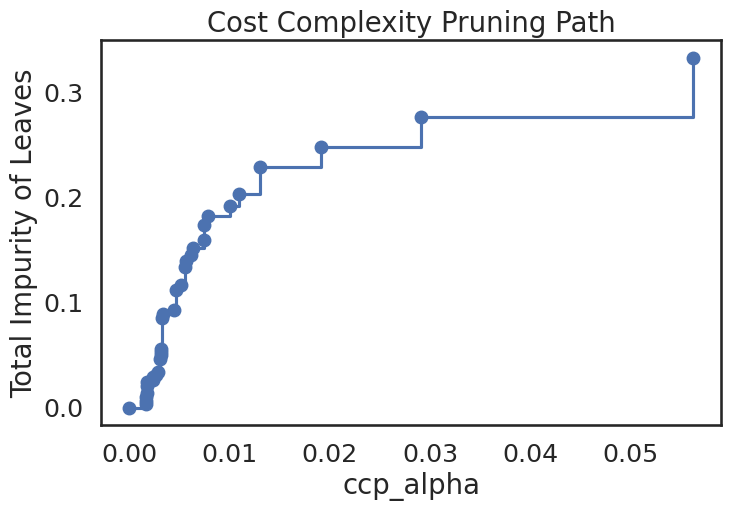

Best ccp_alpha: 0.010005920663114268
Best cross-validated accuracy: 84.55%


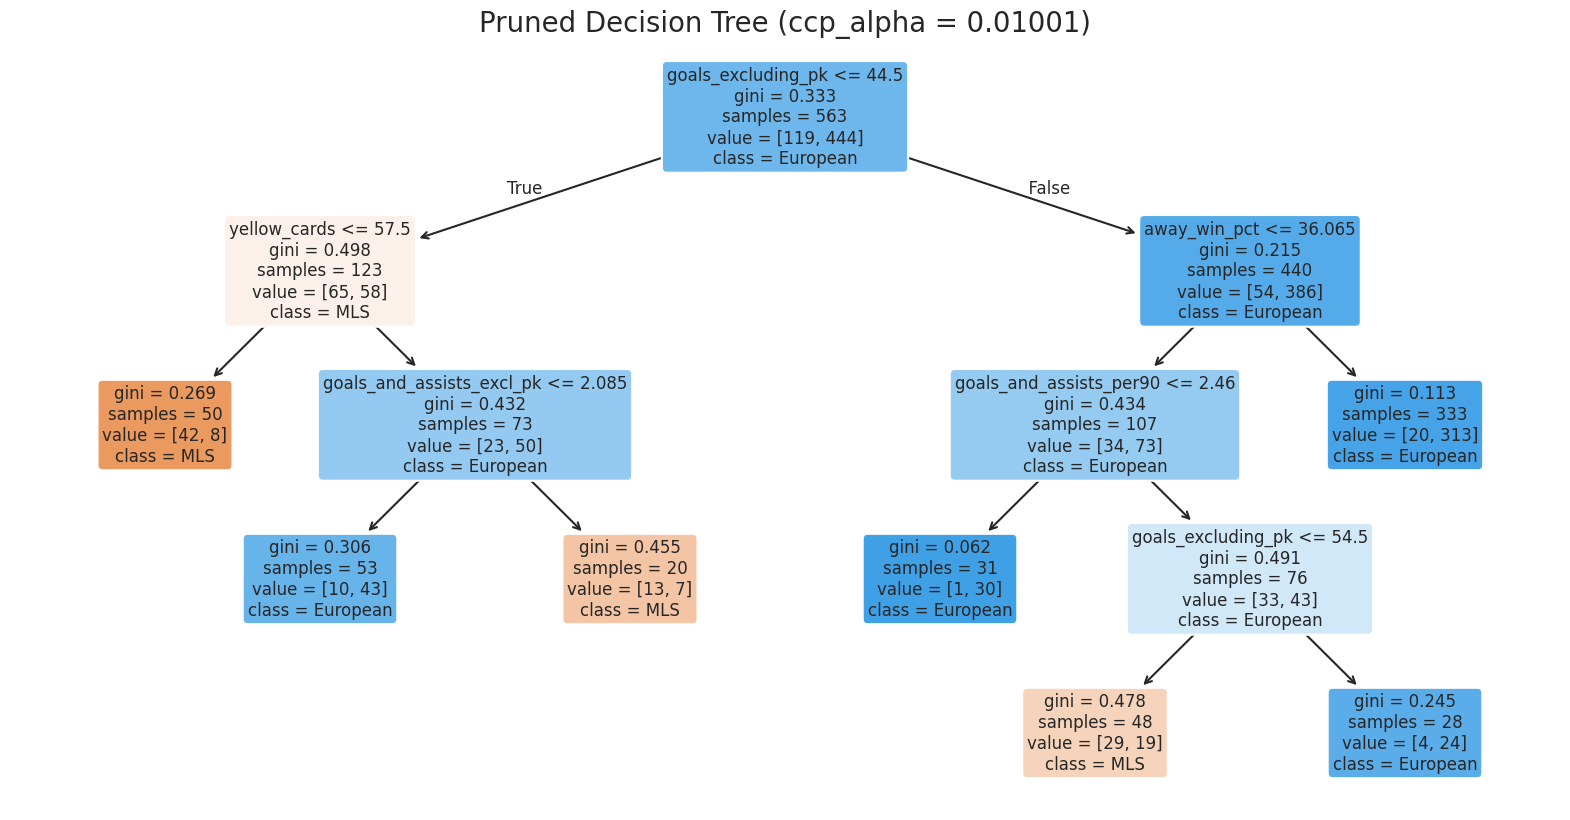

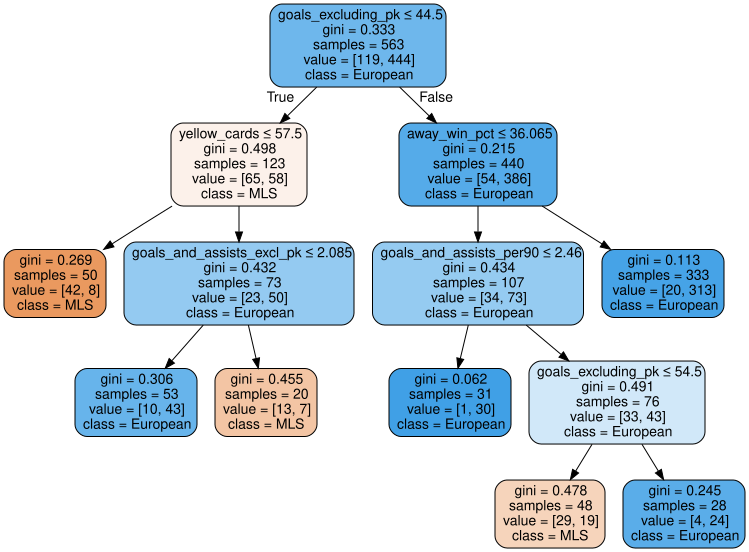

In [83]:
# ----- Step 1: Load and Preprocess the Data -----

# Drop rows with missing values in the features or outcome.
df_model = qualified_fixtures_df.dropna(subset=feature_columns + ["is_european"]).copy()

# Separate predictors and target
X = df_model[feature_columns]
y = df_model["is_european"]


# --- Step 1: Grow a Full Decision Tree with Gini Criterion ---
# Initialize the Decision Tree with Gini as the splitting criterion.
dt_full = DecisionTreeClassifier(random_state=42, criterion="gini")
dt_full.fit(X, y)

# --- Step 2: Obtain the Cost Complexity Pruning Path ---
# This function returns effective alphas and the corresponding total impurity of leaves.
path = dt_full.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Effective ccp_alphas:", ccp_alphas)

# Plot the relationship between ccp_alpha and impurity (optional)
plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
plt.title("Cost Complexity Pruning Path")
plt.xlabel("ccp_alpha")
plt.ylabel("Total Impurity of Leaves")
plt.show()

# --- Step 3: Use Cross-Validation to Find Optimal ccp_alpha ---
# Prepare a grid of candidate ccp_alpha values.
param_grid = {'ccp_alpha': ccp_alphas}

# Initialize a new Decision Tree using the Gini criterion.
dt = DecisionTreeClassifier(random_state=42, criterion="gini")

# Use StratifiedKFold for CV.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=cv, scoring="accuracy")
grid_search.fit(X, y)

print("Best ccp_alpha:", grid_search.best_params_['ccp_alpha'])
print("Best cross-validated accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

# --- Step 4: Train a Pruned Decision Tree ---
optimal_alpha = grid_search.best_params_['ccp_alpha']
dt_pruned = DecisionTreeClassifier(random_state=42, criterion="gini", ccp_alpha=optimal_alpha)
dt_pruned.fit(X, y)

# Optionally, visualize the pruned tree using plot_tree:
plt.figure(figsize=(20, 10))
plot_tree(dt_pruned, feature_names=feature_columns, class_names=["MLS", "European"], filled=True, rounded=True, fontsize=12)
plt.title("Pruned Decision Tree (ccp_alpha = {:.5f})".format(optimal_alpha))
plt.show()

# Optionally, export the tree to Graphviz for a cleaner visualization:
from sklearn.tree import export_graphviz
dot_data = export_graphviz(dt_pruned,
                           out_file=None,
                           feature_names=feature_columns,
                           class_names=["MLS", "European"],
                           filled=True, rounded=True,
                           special_characters=True)
import graphviz
graph = graphviz.Source(dot_data)
graph.render("pruned_decision_tree", format="png")
graph  # in Jupyter Notebook, this displays the image